In [1]:
import pandas as pd
import seaborn as sns
import numpy as np

import matplotlib.pyplot as plt

In [2]:
sns.set_palette("Set2")

In [ ]:
df = pd.read_csv('/Users/m.a.n.nikityukgmail.com/Desktop/Projects/ABD_project_25/ABD_project_25/Churn_Modelling.csv')

**Таблица:** данные содержат сведения о клиентах банка, целевая переменная представляет собой бинарную переменную, отражающую тот факт, покинул ли клиент банк (закрыл свой счет) или продолжает оставаться клиентом.

# Общая информаия

In [5]:
df.shape

(10000, 14)

In [6]:
df.sample(5)

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
2433,2434,15718153,Kao,759,Spain,Female,74,6,128917.84,1,1,1,48244.64,0
7660,7661,15665014,Middleton,458,Spain,Male,36,5,0.00,2,1,0,79723.78,0
4557,4558,15624866,Brewer,658,Germany,Male,37,3,168735.74,2,0,0,70370.24,0
9098,9099,15713559,Onyemauchechukwu,473,Germany,Female,32,5,146602.25,2,1,1,72946.95,0
8706,8707,15717770,Marcelo,850,Spain,Female,55,7,0.00,1,0,0,171762.87,1


In [7]:
df.dtypes

RowNumber            int64
CustomerId           int64
Surname             object
CreditScore          int64
Geography           object
Gender              object
Age                  int64
Tenure               int64
Balance            float64
NumOfProducts        int64
HasCrCard            int64
IsActiveMember       int64
EstimatedSalary    float64
Exited               int64
dtype: object

In [8]:
df.isna().sum().to_frame().rename(columns={0: 'NULL values'})

,NULL values
RowNumber,0
CustomerId,0
Surname,0
CreditScore,0
Geography,0
Gender,0
Age,0
Tenure,0
Balance,0
NumOfProducts,0


In [9]:
df[df.duplicated()]

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited


**Выводы:**
- Датасет содержит 10000 строк и 14 столбцов
- Датасет не содержит пропусков
- Типы данных соответствуют ожидаемым
- Дубли отсутствуют

# Описательные статистики

In [13]:
df.describe(include=['int64', 'float64'])

,RowNumber,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.00000,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,5000.50000,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,2886.89568,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.00000,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,2500.75000,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,5000.50000,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,7500.25000,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,10000.00000,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


In [14]:
df.describe(include=['object'])

,Surname,Geography,Gender
count,10000,10000,10000
unique,2932,3,2
top,Smith,France,Male
freq,32,5014,5457


1.Числовые переменные:<br>
RowNumber:<br>
Среднее значение: 5000.5, что логично, так как это просто порядковый номер строки.<br>
Минимальное значение: 1, максимальное: 10000, что соответствует количеству строк в данных.<br>

CustomerId:<br>
Среднее значение: 1.56e+07 (15,600,940), стандартное отклонение: 71,936.19.<br>
Минимальное значение: 15,565,700, максимальное: 15,815,590. Это уникальные идентификаторы клиентов.<br>

CreditScore:<br>
Средний кредитный рейтинг: 650.53, стандартное отклонение: 96.65.<br>
Минимальное значение: 350, максимальное: 850. Это соответствует стандартному диапазону кредитных рейтингов.<br>

Age:<br>
Средний возраст клиентов: 38.92 года, стандартное отклонение: 10.49.<br>
Минимальный возраст: 18 лет, максимальный: 92 года. Возраст клиентов варьируется от молодых до пожилых.<br>

Tenure:<br>
Средний срок пребывания клиента: 5.01 года, стандартное отклонение: 2.89.<br>
Минимальное значение: 0 лет, максимальное: 10 лет. Это указывает на то, что некоторые клиенты только что присоединились.<br>

Balance:<br>
Средний баланс на счетах: 76,485.89, стандартное отклонение: 62,397.41.<br>
Минимальное значение: 0, максимальное: 250,898.09. У некоторых клиентов баланс равен нулю, что может указывать на неактивные счета.

NumOfProducts:<br>
Среднее количество продуктов: 1.53, стандартное отклонение: 0.58.<br>
Минимальное значение: 1, максимальное: 4. Большинство клиентов используют 1-2 продукта.<br>

HasCrCard:<br>
Среднее значение: 0.7055, что означает, что около 70.55% клиентов имеют кредитную карту.<br>

IsActiveMember:<br>
Среднее значение: 0.5151, что означает, что около 51.51% клиентов являются активными.<br>

EstimatedSalary:<br>
Средняя зарплата: 100,000.24, стандартное отклонение: 57,510.49.<br>
Минимальное значение: 11.58, максимальное: 199,992.48. Зарплаты варьируются от очень низких до высоких.<br>

Exited:<br>
Среднее значение: 0.2037, что означает, что около 20.37% клиентов ушли (прекратили пользоваться услугами).<br>

2.Категориальные переменные:<br>
Surname:<br>
Уникальных фамилий: 2932. Наиболее часто встречающаяся фамилия: "Smith" (32 раза).<br>

Geography:<br>
Уникальных значений: 3. Наиболее часто встречающаяся страна: "France" (5014 раз).<br>

Gender:<br>
Уникальных значений: 2. Наиболее часто встречающийся пол: "Male" (5457 раз).<br>

**Выводы:**
- В колонках `CreditScore`, `Age`, `Tenure` распределене, возможно, похоже на нормальное
- Судя по разнице между `mean` и `median`, `75%` и `max` в `Balance` возможны выбросы
- `HasCrCard`, `IsActiveMember` и `Exited` являются переменными-флагами, поэтому в них значение `mean` равно доле значений True для соответствующего признака. В `IsActiveMember` оно равно примерно половине, а в `HasCrCard` и `Exited` есть дисбаланс
- В `Geography` из трех возможных значений самое частотное встречается чаще, чем в 50% строках -> дисбаланс
- `Surname` имеет слишком много уникальных значений

# Детальная информация по признакам

In [15]:
df.columns

Index(['RowNumber', 'CustomerId', 'Surname', 'CreditScore', 'Geography',
       'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard',
       'IsActiveMember', 'EstimatedSalary', 'Exited'],
      dtype='object')

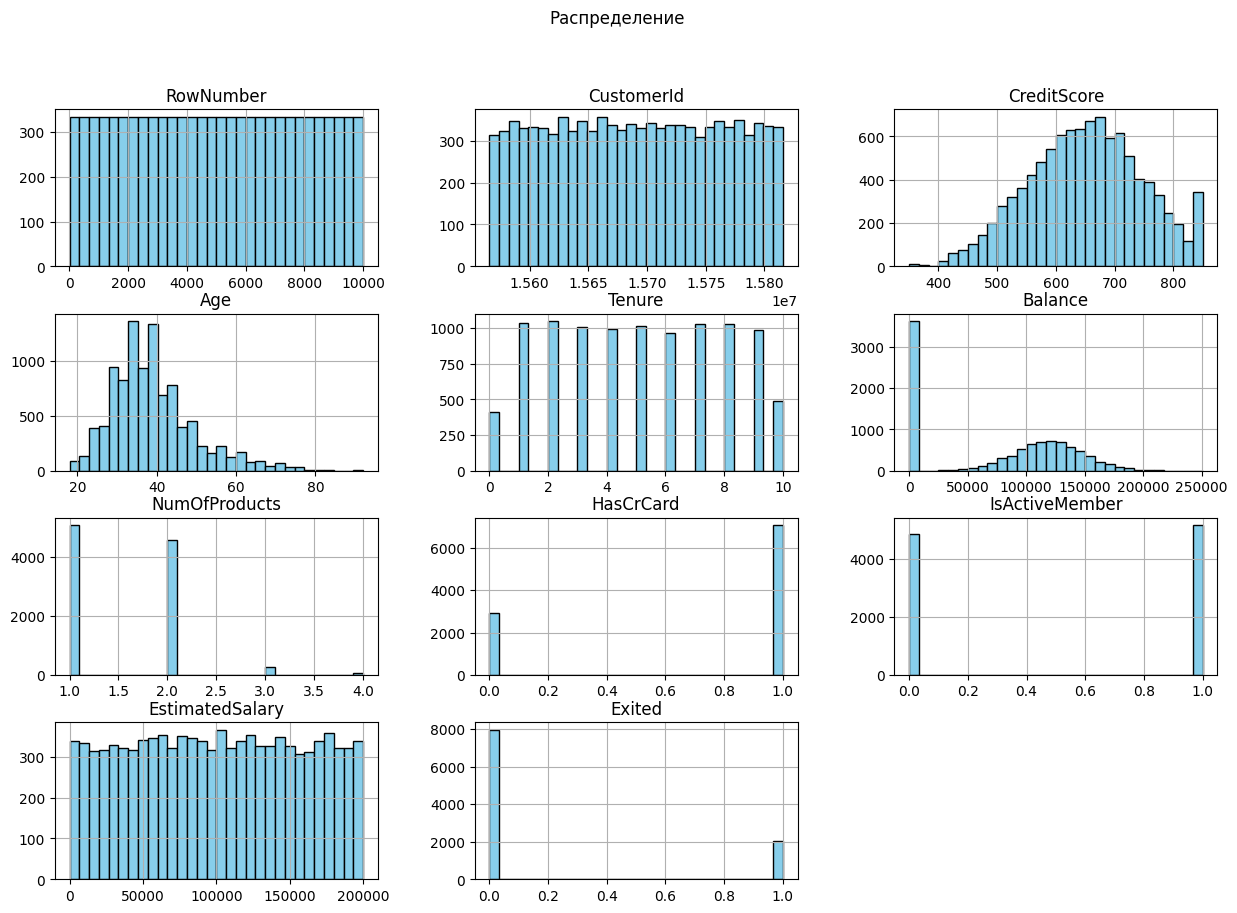

In [10]:
df.hist(bins=30, figsize=(15, 10), color='skyblue', edgecolor='black')

plt.suptitle('Распределение')
plt.show()

In [11]:
# Детализация распределений

for col in df.columns:
    print(f"Признак: {col}")
    print(df[col].value_counts(normalize=True).map(lambda x: "{0:.2f}%".format(100 * x)))


Признак: RowNumber
RowNumber
1        0.01%
6671     0.01%
6664     0.01%
6665     0.01%
6666     0.01%
         ...  
3334     0.01%
3335     0.01%
3336     0.01%
3337     0.01%
10000    0.01%
Name: proportion, Length: 10000, dtype: object
Признак: CustomerId
CustomerId
15634602    0.01%
15667932    0.01%
15766185    0.01%
15667632    0.01%
15599024    0.01%
            ...  
15599078    0.01%
15702300    0.01%
15660735    0.01%
15671390    0.01%
15628319    0.01%
Name: proportion, Length: 10000, dtype: object
Признак: Surname
Surname
Smith       0.32%
Scott       0.29%
Martin      0.29%
Walker      0.28%
Brown       0.26%
            ...  
Izmailov    0.01%
Bold        0.01%
Bonham      0.01%
Poninski    0.01%
Burbidge    0.01%
Name: proportion, Length: 2932, dtype: object
Признак: CreditScore
CreditScore
850    2.33%
678    0.63%
655    0.54%
705    0.53%
667    0.53%
       ...  
404    0.01%
351    0.01%
365    0.01%
417    0.01%
419    0.01%
Name: proportion, Length: 460, dtype: 

### Проверка на выбросы

In [12]:
from scipy.stats import zscore

numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
z_scores = np.abs(zscore(df[numerical_cols]))
outliers = (z_scores > 3).sum(axis=0)
print("\nКол-во выбросов по каждому числовому признаку (|z|>3):\n", dict(zip(numerical_cols, outliers)))


Кол-во выбросов по каждому числовому признаку (|z|>3):
 {'RowNumber': 0, 'CustomerId': 0, 'CreditScore': 8, 'Age': 133, 'Tenure': 0, 'Balance': 0, 'NumOfProducts': 60, 'HasCrCard': 0, 'IsActiveMember': 0, 'EstimatedSalary': 0, 'Exited': 0}


**Выводы:** выбросы найденых только в тех признаках, для которых распределения отличаются от нормальных

### RowNumber, CustomerId и Surname - кандидаты для исключения из модели

In [16]:
df.RowNumber.nunique()

10000

In [17]:
df.CustomerId.nunique()

10000

In [18]:
df.Surname.nunique()

2932

#### `RowNumber`

Text(0, 0.5, 'Частота')

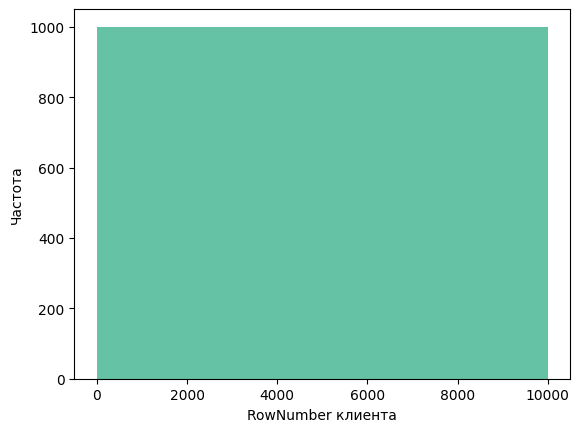

In [86]:
df.RowNumber.plot(kind='hist')

plt.xlabel('RowNumber клиента')
plt.ylabel('Частота')

* `RowNumber` - монотонно присваиваемый код клиента

#### `Customer ID`

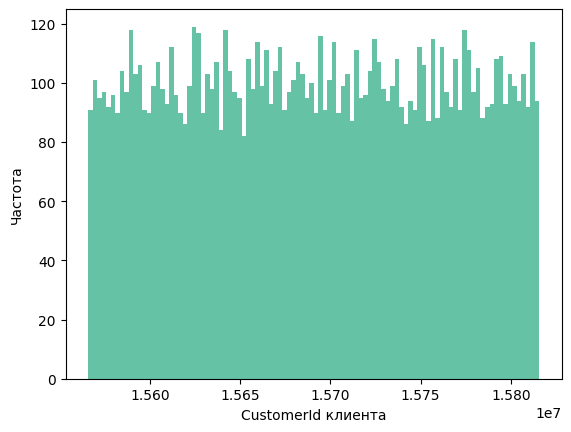

In [98]:
df.CustomerId.plot(kind='hist', bins=100)

plt.xlabel('CustomerId клиента')
plt.ylabel('Частота')

plt.show()

In [90]:
df.CustomerId.value_counts()

CustomerId
15628319    1
15634602    1
15647311    1
15619304    1
15701354    1
           ..
15568982    1
15577657    1
15597945    1
15699309    1
15725737    1
Name: count, Length: 10000, dtype: int64

* Несмотря на уникальность `ID` клиентов, это не монотонно присваиваемые номера (что можно наблюдать по гистограмме), возможно в системе хранения данных о клиентах присутствует некоторое правило присвоения уникального индекса пользователю. Однако полезной информации это не несет.

#### `Surname`

Так как данные с фамилиями не несут сильно полезной информации для дальнейшего анализа, можно из интересно изучить распределение **длины** фамилий.

In [121]:
small_df = pd.concat([df[['Surname', 'Gender', 'Exited']], df['Surname'].str.len()], axis=1)
small_df.columns = ['Surname', 'Gender', 'Exited', 'Sur_len']
small_df.head()


,Surname,Gender,Exited,Sur_len
0,Hargrave,Female,1,8
1,Hill,Female,0,4
2,Onio,Female,1,4
3,Boni,Female,0,4
4,Mitchell,Female,0,8


Количество уникальных фамилий: 2932
Наиболее часто встречающаяся фамилия: Smith
Количество её повторений: 32


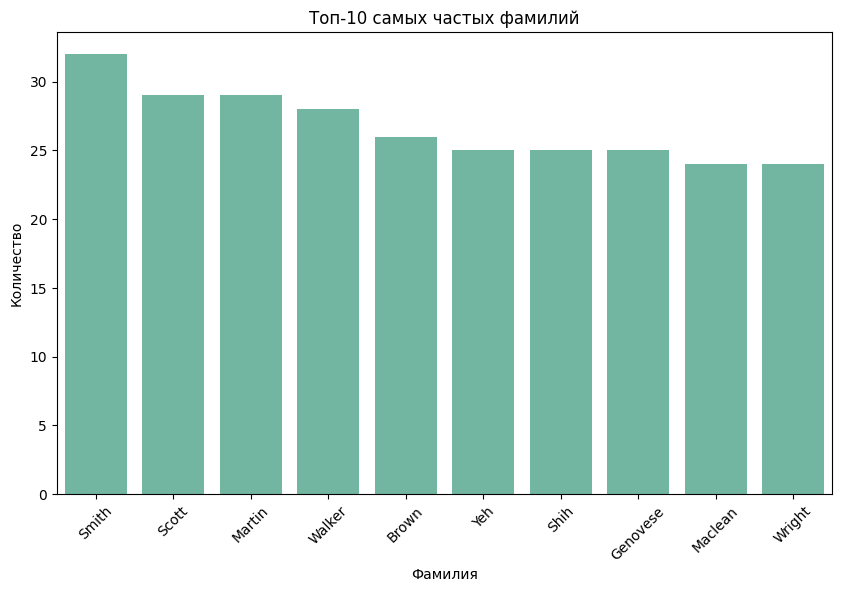

In [16]:
print("Количество уникальных фамилий:", df['Surname'].nunique())
print("Наиболее часто встречающаяся фамилия:", df['Surname'].mode()[0])
print("Количество её повторений:", df['Surname'].value_counts().max())

top_surnames = df['Surname'].value_counts().head(10)

plt.figure(figsize=(10, 6))
sns.barplot(x=top_surnames.index, y=top_surnames.values)
plt.title("Топ-10 самых частых фамилий")
plt.xlabel("Фамилия")
plt.ylabel("Количество")
plt.xticks(rotation=45)
plt.show()

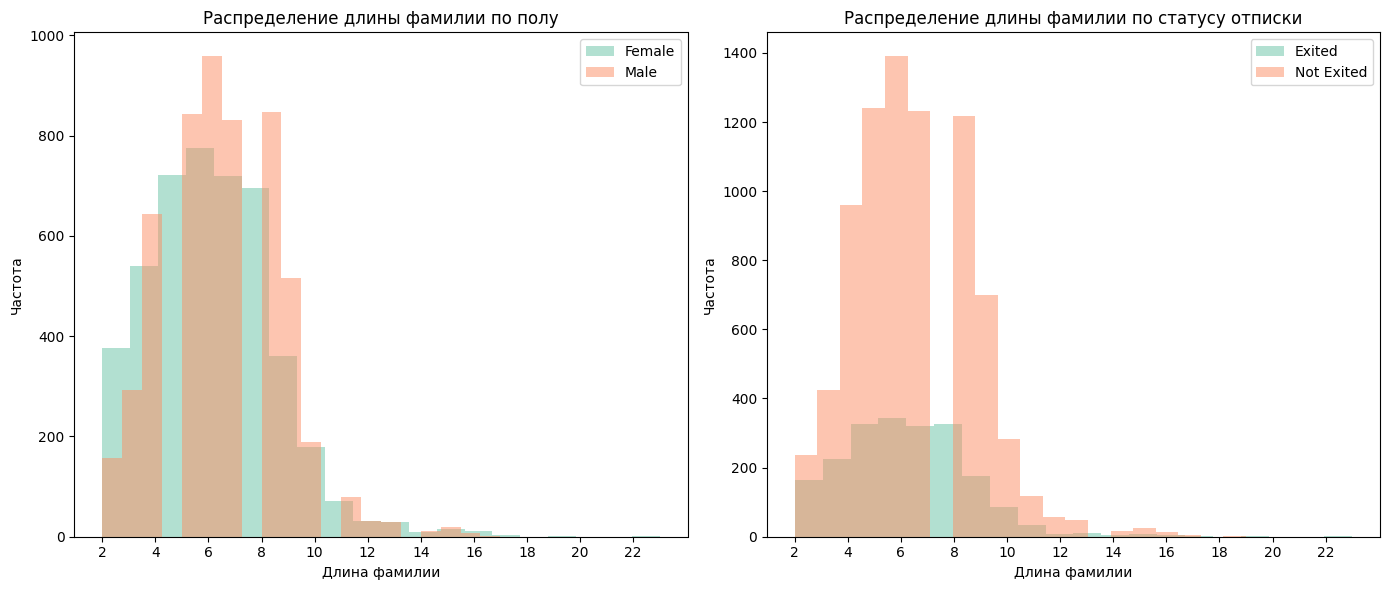

In [123]:
fig, axs = plt.subplots(1, 2, figsize=(14, 6))

small_df[small_df['Gender'] == 'Female']['Sur_len'].plot(kind='hist', bins=20, alpha=0.5, label='Female', ax=axs[0], stacked=True)
small_df[small_df['Gender'] == 'Male']['Sur_len'].plot(kind='hist', bins=20, alpha=0.5, label='Male', ax=axs[0], stacked=True)
axs[0].legend()
axs[0].set_title('Распределение длины фамилии по полу')
axs[0].set_xlabel('Длина фамилии')
axs[0].set_ylabel('Частота')
axs[0].set_xticks(range(min(small_df['Sur_len']), max(small_df['Sur_len'])+1, 2))

small_df[small_df['Exited'] == 1]['Sur_len'].plot(kind='hist', bins=20, alpha=0.5, label='Exited', ax=axs[1], stacked=True)
small_df[small_df['Exited'] == 0]['Sur_len'].plot(kind='hist', bins=20, alpha=0.5, label='Not Exited', ax=axs[1], stacked=True)
axs[1].legend()
axs[1].set_title('Распределение длины фамилии по статусу отписки')
axs[1].set_xlabel('Длина фамилии')
axs[1].set_ylabel('Частота')
axs[1].set_xticks(range(min(small_df['Sur_len']), max(small_df['Sur_len'])+1, 2))

plt.tight_layout()
plt.show()

* При первоначальном осмотре уникальных фамилий сложилось впечатление, что фамилии **сгенерированы**
* Левый график показывает, что в среднем длина фамилии составляет от 5 до 8 символов
* Уже сейчас по графику можно заметить, что девушек в датасете меньше (но об этом позже)
---
* По второму графику точно нельзя сказать о том, что длина фамилии влияет на статус отписки от сервиса - распределения практически совпадают, различается лишь количество

**Вывод:** `RowNumber`, `CustomerId` - идентификаторы, не подлежат анализу. `Surname` - фамилия клиента, не имеет значения в рамках решаемой задачи

### Exited - целевая переменная - покинул ли клиент банк

In [19]:
df.Exited.nunique()

2

In [20]:
df.Exited.unique()

array([1, 0])

Text(0.5, 1.0, 'Распределение статусов отписки')

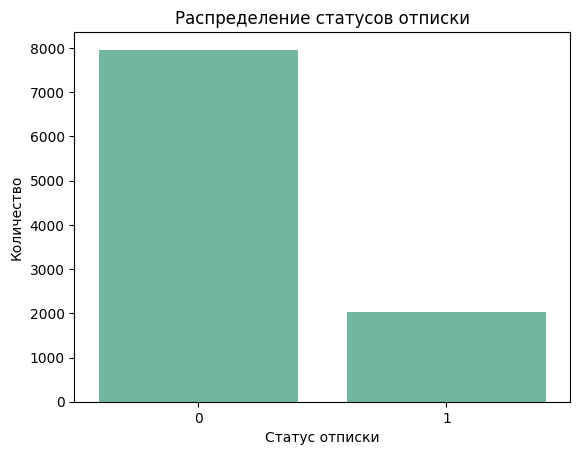

In [125]:
ax = sns.barplot(df.groupby('Exited', as_index=False).size(), x='Exited', y='size');

ax.set_xlabel('Статус отписки')
ax.set_ylabel('Количество')
ax.set_title('Распределение статусов отписки')

In [22]:
df.Exited.mean() * 100

np.float64(20.369999999999997)

**Вывод:** значения `Exited` соответствуют ожидаемым. По данным доля клиентов, покинувших банк - 20%

### CreditScore - кредитный рейтинг клиента

In [23]:
df.CreditScore.nunique()

460

Text(0.5, 1.0, 'Распределение кредитных рейтингов в разрезе статуса отписки')

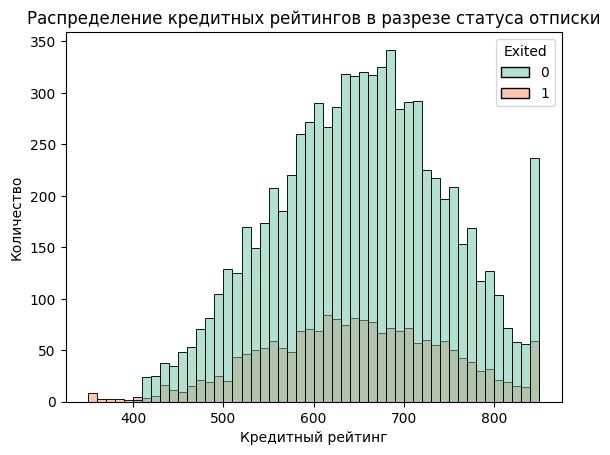

In [127]:
ax = sns.histplot(df, x='CreditScore', bins=50, hue='Exited')
ax.set_xlabel('Кредитный рейтинг')
ax.set_ylabel('Количество')
ax.set_title('Распределение кредитных рейтингов в разрезе статуса отписки')

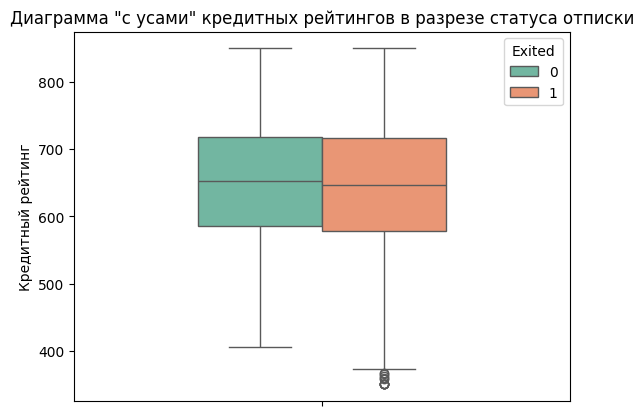

In [133]:
sns.boxplot(df, y='CreditScore', hue='Exited', width=0.5)
plt.ylabel('Кредитный рейтинг')
plt.title('Диаграмма "с усами" кредитных рейтингов в разрезе статуса отписки')

plt.show()


In [ ]:
print(f"min = {df.CreditScore.min()}, max = {df.CreditScore.max()}")

min = 350, max = 850


**Вывод:** распределение `CreditScore` в целом похоже на нормальное, но максимальные значения слишком частотные. Клиенты, покинувшие банк и оставшиеся, в целом, имеют похожий кредитный рейтинг

### Geography - страна

In [27]:
df.Geography.unique()

array(['France', 'Spain', 'Germany'], dtype=object)

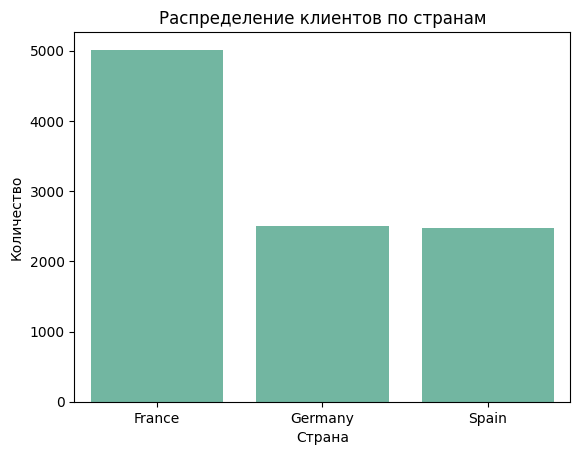

In [135]:
ax = sns.barplot(df.groupby(['Geography'], as_index=False).size(), x='Geography', y='size')
ax.set_xlabel('Страна')
ax.set_ylabel('Количество')
ax.set_title('Распределение клиентов по странам')

plt.show()

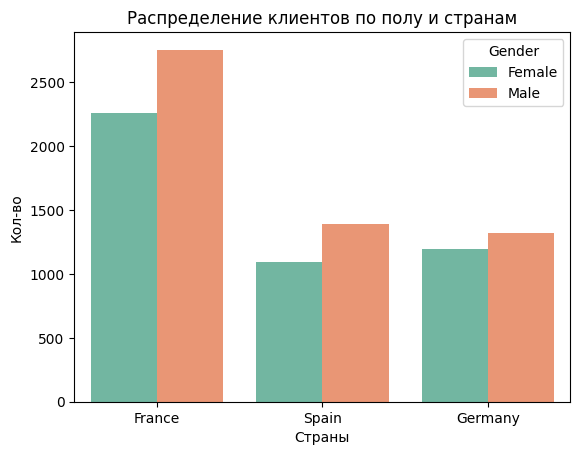

In [74]:
sns.countplot(data=df, x='Geography', hue='Gender')

plt.xlabel('Страны')
plt.ylabel('Кол-во')
plt.title('Распределение клиентов по полу и странам')

plt.show()


Text(0.5, 1.0, 'Распределение клиентов по странам в разрезе статуса отписки')

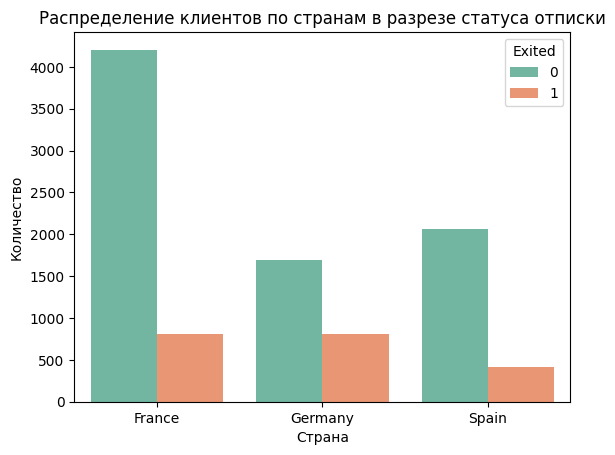

In [137]:
ax = sns.barplot(df.groupby(['Geography', 'Exited'], as_index=False).size(), x='Geography', y='size', hue='Exited')
ax.set_xlabel('Страна')
ax.set_ylabel('Количество')
ax.set_title('Распределение клиентов по странам в разрезе статуса отписки')

In [30]:
df.groupby(['Geography'], as_index=False).agg(count=('Exited', 'count'), exited_share=('Exited', 'mean'))

,Geography,count,exited_share
0,France,5014,0.161548
1,Germany,2509,0.324432
2,Spain,2477,0.166734


**Вывод:** 
- Половина клиентов из Франции
- Процент оттока для Франции и Испании одинаковй, а для Germany он выше

-> скорее всего, страна влияет на решение клиента покинуть банк

### Gender - пол клиента

In [31]:
df.Gender.unique()

array(['Female', 'Male'], dtype=object)

In [1]:
df.groupby(['Gender'], as_index=False).size()


KeyboardInterrupt



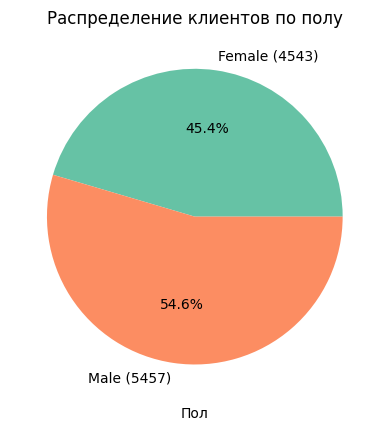

In [5]:
sizes = df.groupby(['Gender'], as_index=False).size()['size']
labels = [f"{label} ({size})" for label, size in zip(df.Gender.unique(), sizes)]
plt.pie(sizes, labels=labels, autopct='%1.1f%%')

plt.xlabel('Пол')
plt.ylabel('')
plt.title('Распределение клиентов по полу')

plt.show()

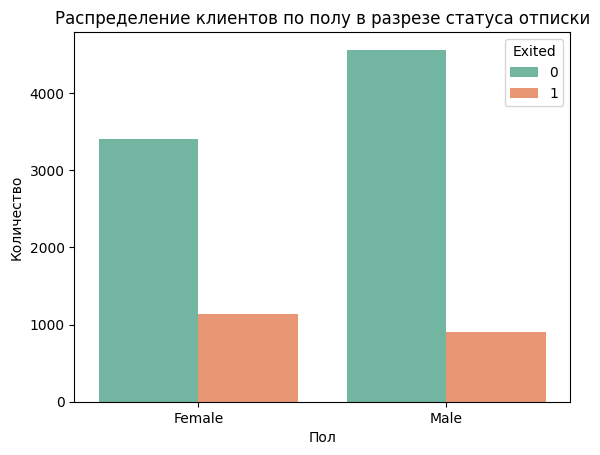

In [7]:
ax = sns.barplot(df.groupby(['Gender', 'Exited'], as_index=False).size(), x='Gender', y='size', hue='Exited')
ax.set_xlabel('Пол')
ax.set_ylabel('Количество')
ax.set_title('Распределение клиентов по полу в разрезе статуса отписки')

plt.show()

In [34]:
df.groupby(['Gender'], as_index=False).agg(count=('Exited', 'count'), exited_share=('Exited', 'mean'))

,Gender,count,exited_share
0,Female,4543,0.250715
1,Male,5457,0.164559


**Вывод:** 
- Вероятно, пол влияет на решение покинуть банк, т.к. среди женщин доля отказавшихся от услуг в 1.5 раза больше

### Age - возраст клиента

In [35]:
df.Age.nunique()

70

In [36]:
print(f"min = {df.Age.min()}, max = {df.Age.max()}")

min = 18, max = 92


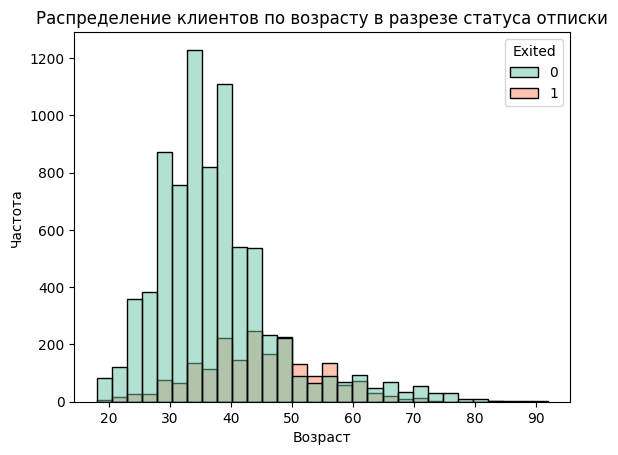

In [8]:
ax = sns.histplot(df, x='Age', bins=30, hue='Exited')
ax.set_xlabel('Возраст')
ax.set_ylabel('Частота')
ax.set_title('Распределение клиентов по возрасту в разрезе статуса отписки')

plt.show()

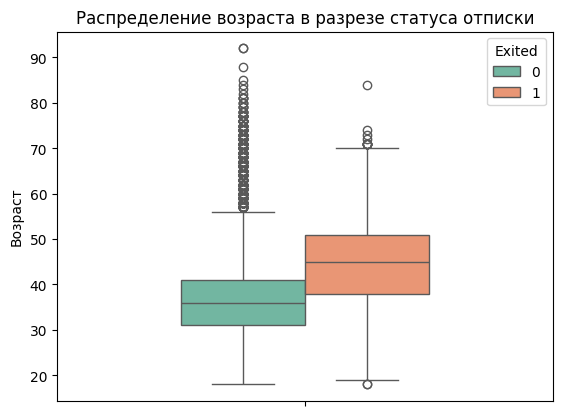

In [10]:
ax = sns.boxplot(df, y='Age', hue='Exited', width=0.5)
ax.set_ylabel('Возраст')
ax.set_title('Распределение возраста в разрезе статуса отписки')

plt.show()

**Вывод:** 
- Распределение отличается от нормального -> нужны преобразованя
- Возможно, клиенты старшего возраста больше склонны к отказу от услуг банка

### Tenure - сколько лет клиент пользуется банком

In [39]:
df.Tenure.unique()

array([ 2,  1,  8,  7,  4,  6,  3, 10,  5,  9,  0])

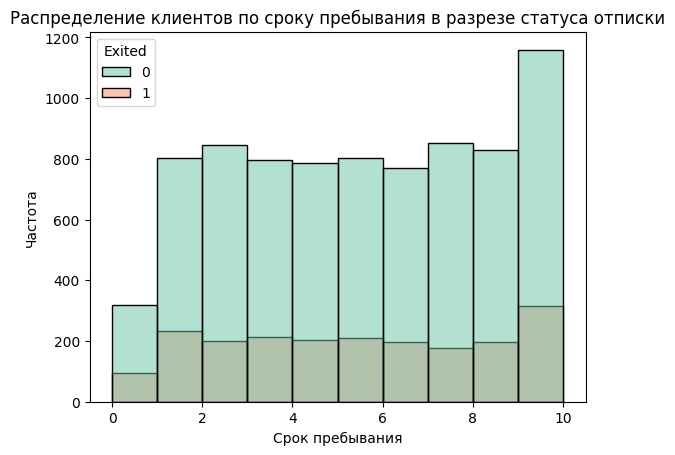

In [11]:
ax = sns.histplot(df, x='Tenure', bins=10, hue='Exited')
ax.set_xlabel('Срок пребывания')
ax.set_ylabel('Частота')
ax.set_title('Распределение клиентов по сроку пребывания в разрезе статуса отписки')

plt.show()

**Вывод:** 
- Распределение близко к равномерному -> влияния на целевую переменную нет

### Balance - баланс банковского счета клиента

In [41]:
print(f"min = {df.Balance.min()}, max = {df.Balance.max()}")

min = 0.0, max = 250898.09


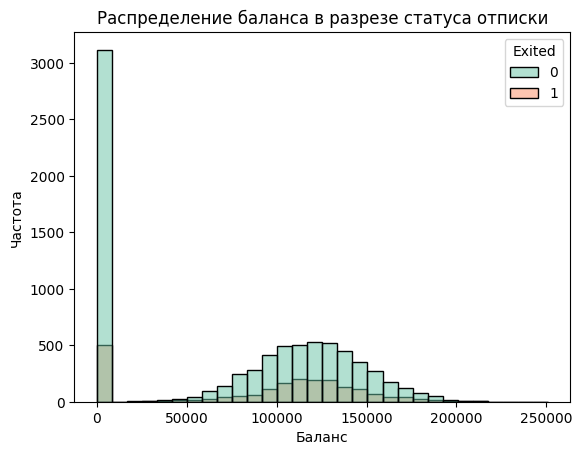

In [12]:
ax = sns.histplot(df, x='Balance', bins=30, hue='Exited')
ax.set_xlabel('Баланс')
ax.set_ylabel('Частота')
ax.set_title('Распределение баланса в разрезе статуса отписки')

plt.show()

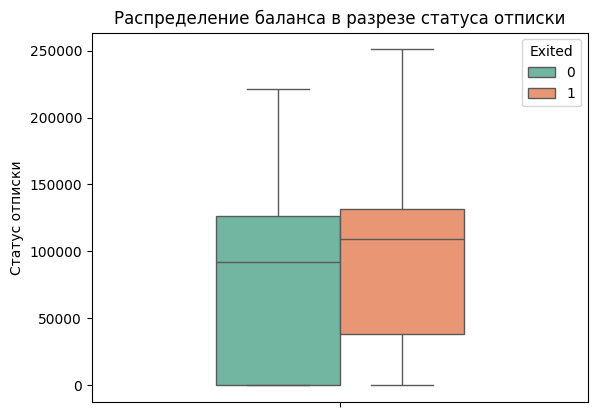

In [14]:
ax = sns.boxplot(df, y='Balance', hue='Exited', width=0.5)
ax.set_ylabel('Статус отписки')

ax.set_title('Распределение баланса в разрезе статуса отписки')

plt.show()

**Вывод:** 
- Много клиентов с нулевым балансом
- Среди клиентов с нулевым балансом доля отказов выше, чем среди клиентов с ненулевым балансом
- Распределение клиентов с ненулевым балансом близко к нормальному

### NumOfProducts - количество банковских продуктов, которыми пользуется клиент

In [44]:
df.NumOfProducts.unique()

array([1, 3, 2, 4])

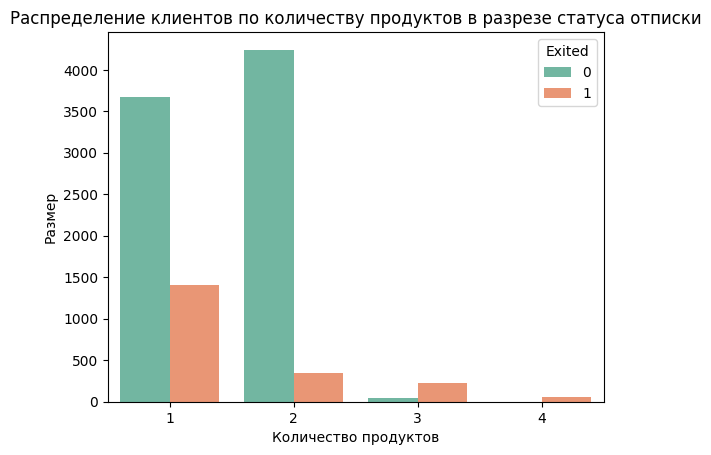

In [15]:
ax = sns.barplot(df.groupby(['NumOfProducts', 'Exited'], as_index=False).size(), x='NumOfProducts', y='size', hue='Exited')
ax.set_xlabel('Количество продуктов')
ax.set_ylabel('Размер')
ax.set_title('Распределение клиентов по количеству продуктов в разрезе статуса отписки')

plt.show()

In [46]:
df.groupby(['NumOfProducts'], as_index=False).agg(count=('Exited', 'count'), exited_share=('Exited', 'mean'))

,NumOfProducts,count,exited_share
0,1,5084,0.277144
1,2,4590,0.075817
2,3,266,0.827068
3,4,60,1.000000


**Вывод:** 
- Есть дисбаланс в классах -> можно объединить клиентов, имеющих 3 или 4 продукта в один класс
- Самый низкий процент оттока среди клиентов, имеющих 2 продутка

### HasCrCard - есть ли у клиента кредитная карта

In [47]:
df.HasCrCard.unique()

array([1, 0])

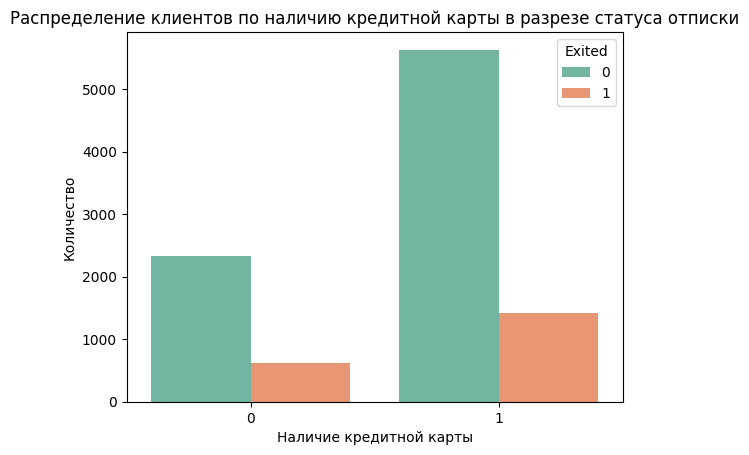

In [16]:
ax = sns.barplot(df.groupby(['HasCrCard', 'Exited'], as_index=False).size(), x='HasCrCard', y='size', hue='Exited')
ax.set_xlabel('Наличие кредитной карты')
ax.set_ylabel('Количество')
ax.set_title('Распределение клиентов по наличию кредитной карты в разрезе статуса отписки')

plt.show()

In [49]:
df.groupby(['HasCrCard'], as_index=False).agg(count=('HasCrCard', 'count'), exited_share=('Exited', 'mean'))

,HasCrCard,count,exited_share
0,0,2945,0.208149
1,1,7055,0.201843


**Вывод:** у большей части клиентов имеется кредитная карта, однако ее наличие не влияет на решение о том, чтобы покинуть банк

### IsActiveMember - является ли клиент активным пользователем

In [50]:
df.HasCrCard.unique()

array([1, 0])

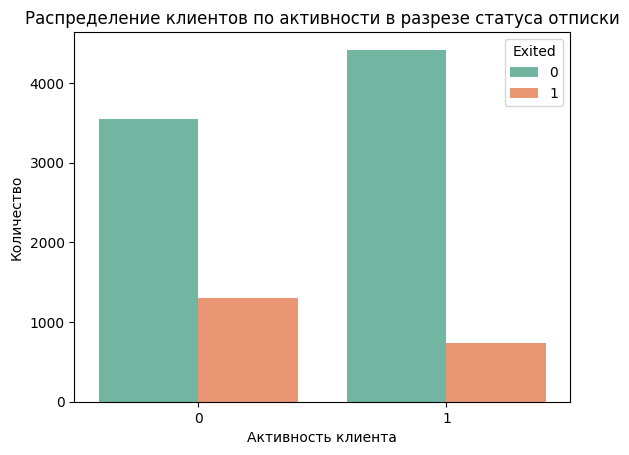

In [17]:
ax = sns.barplot(df.groupby(['IsActiveMember', 'Exited'], as_index=False).size(), x='IsActiveMember', y='size', hue='Exited')
ax.set_xlabel('Активность клиента')
ax.set_ylabel('Количество')
ax.set_title('Распределение клиентов по активности в разрезе статуса отписки')

plt.show()

In [52]:
df.groupby(['IsActiveMember'], as_index=False).agg(count=('IsActiveMember', 'count'), exited_share=('Exited', 'mean'))

,IsActiveMember,count,exited_share
0,0,4849,0.268509
1,1,5151,0.142691


**Вывод**:
- Доля активных и неактивных клиентов примерно одинаковая
- Активные клиенты отказываются от баконковских услуг почти в 2 раза реже

### EstimatedSalary - предполагаемая заработанная плата клиента

In [53]:
print(f"min = {df.EstimatedSalary.min()}, max = {df.EstimatedSalary.max()}")

min = 11.58, max = 199992.48


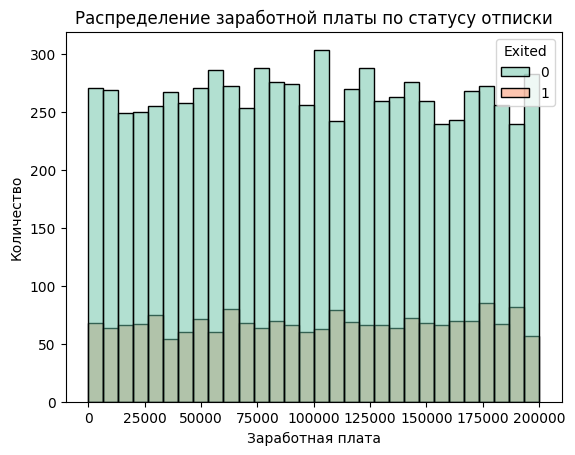

In [20]:
ax = sns.histplot(df, x='EstimatedSalary', bins=30, hue='Exited')
ax.set_xlabel('Заработная плата')
ax.set_ylabel('Количество')
ax.set_title('Распределение заработной платы по статусу отписки')

plt.show()

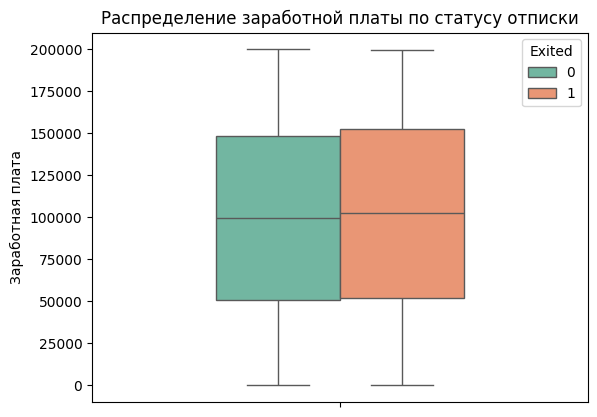

In [22]:
ax = sns.boxplot(df, y='EstimatedSalary', hue='Exited', width=0.5)
ax.set_ylabel('Заработная плата')
ax.set_title('Распределение заработной платы по статусу отписки')

plt.show()

**Вывод:**
- Распределения похожи -> вероятно, нет влияения на целевую переменную
- Распределения близки к равномерным. Для заработной платы это нетипично. Возможно, есть ошибка в данных

# Корреляции и зависимость между переменными

Рассчитаем корреляцию через `phik`. Метод позволяет вычислять взаимосвязи между различными типами признаков (категориальными, непрерывными и их комбинациями), в нем используются передовые статистические алгоритмы

In [ ]:
import phik

interval columns not set, guessing: ['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Exited']


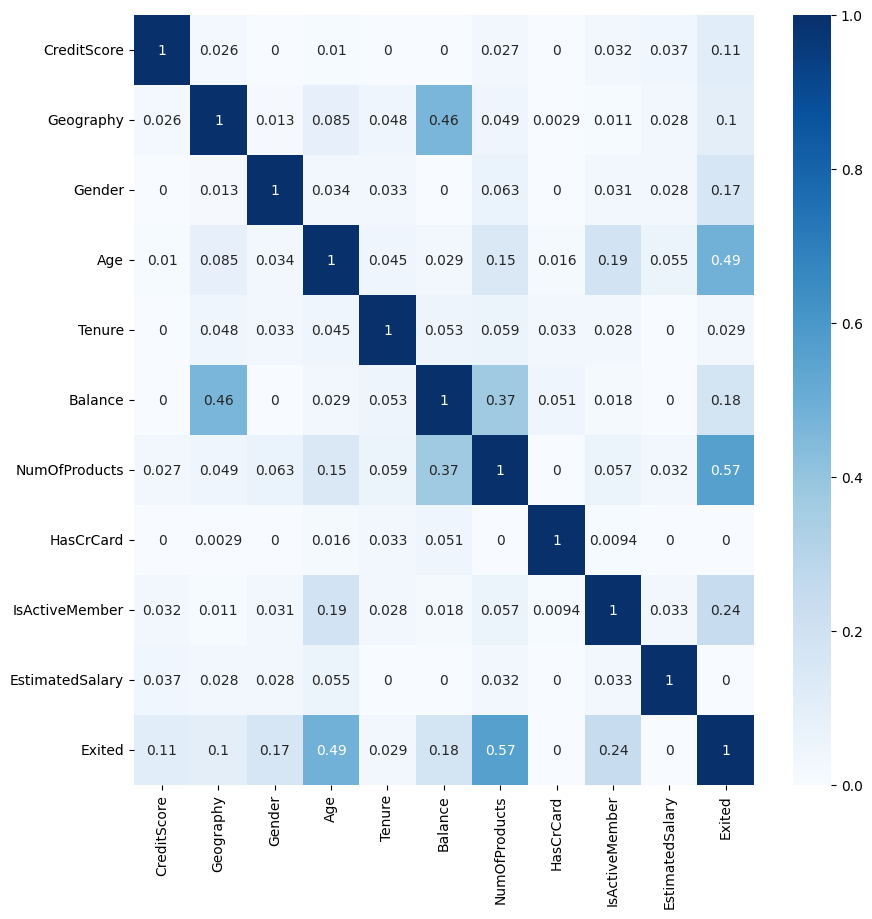

In [147]:
plt.figure(figsize=(10,10))

ph = df.drop(columns=['RowNumber', 'CustomerId', 'Surname']).phik_matrix()
sns.heatmap(ph, cmap="Blues", annot=True);

Рассмотрим зависимости между нецелевыми переменными

#### Geography и Balance

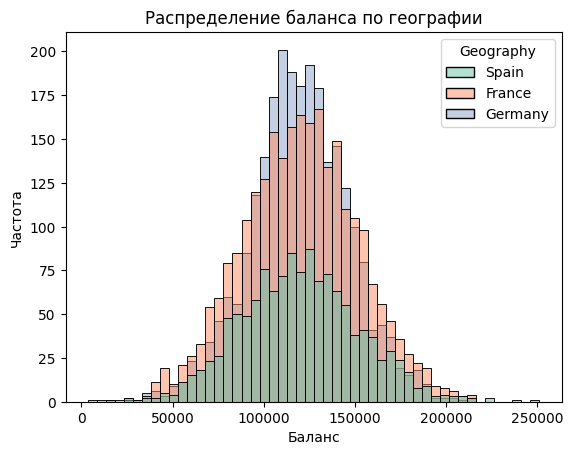

In [23]:
sns.histplot(df.query("Balance != 0"), x='Balance', bins=50, hue='Geography')
plt.xlabel('Баланс')
plt.ylabel('Частота')
plt.title('Распределение баланса по географии')

plt.show()

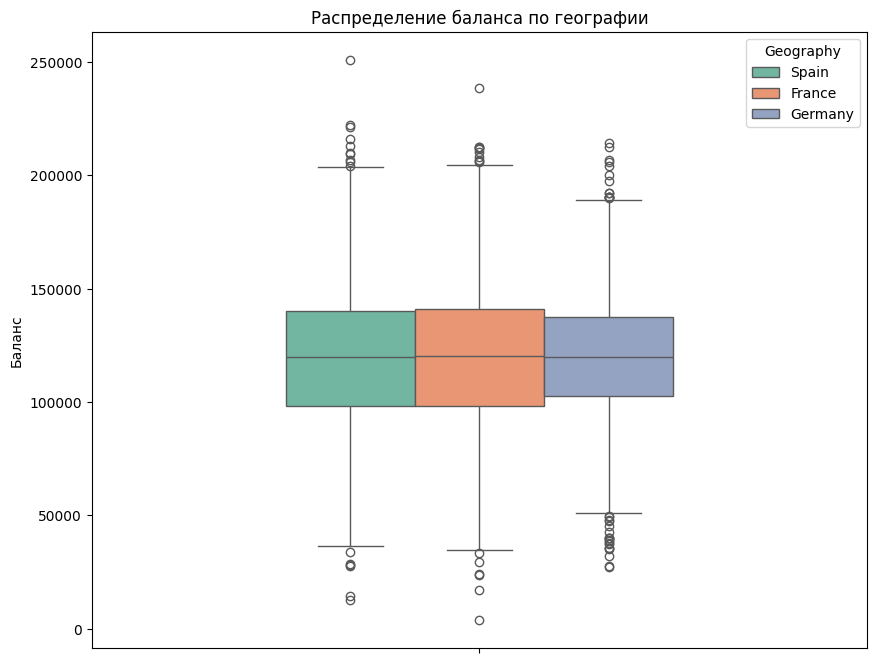

In [25]:
plt.figure(figsize=(10, 8))
sns.boxplot(df.query("Balance != 0"), y='Balance', hue='Geography', width=0.5)
plt.ylabel('Баланс')
plt.title('Распределение баланса по географии')

plt.show()

In [157]:
df['IsNullBalance'] = df.Balance.apply(lambda x: int(x == 0))

In [158]:
df.groupby(['Geography'], as_index=False).IsNullBalance.mean()

,Geography,IsNullBalance
0,France,0.482250
1,Germany,0.000000
2,Spain,0.484053


**Вывод:** в Германии нет клиентов с нулевым балансом -> смещение в данных

### Age и NumOfProducts

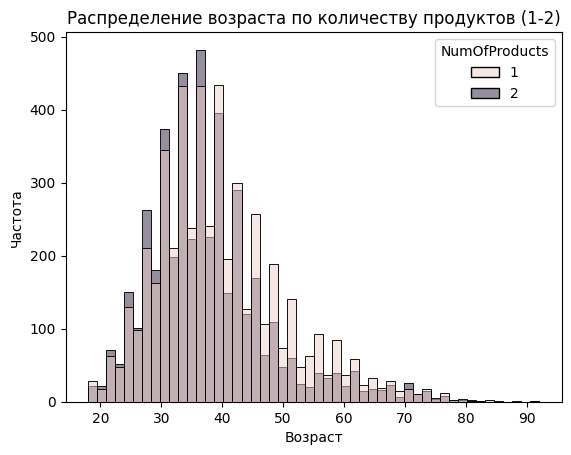

In [29]:
sns.histplot(df.query("NumOfProducts == 1 or NumOfProducts == 2"), x='Age', bins=50, hue='NumOfProducts')
plt.xlabel('Возраст')
plt.ylabel('Частота')
plt.title('Распределение возраста по количеству продуктов (1-2)')

plt.show()

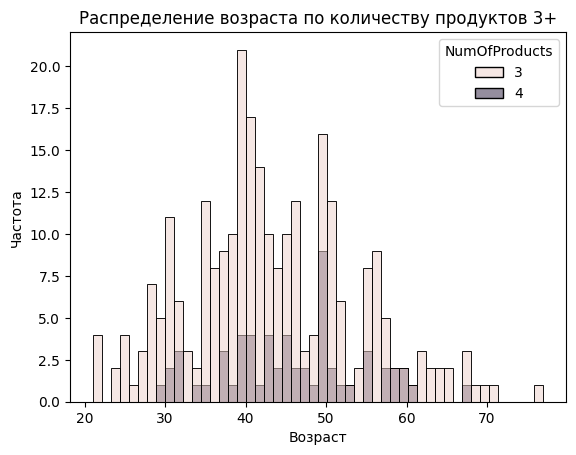

In [28]:
sns.histplot(df.query("NumOfProducts == 3 or NumOfProducts == 4"), x='Age', bins=50, hue='NumOfProducts')
plt.xlabel('Возраст')
plt.ylabel('Частота')
plt.title('Распределение возраста по количеству продуктов 3+')

plt.show()

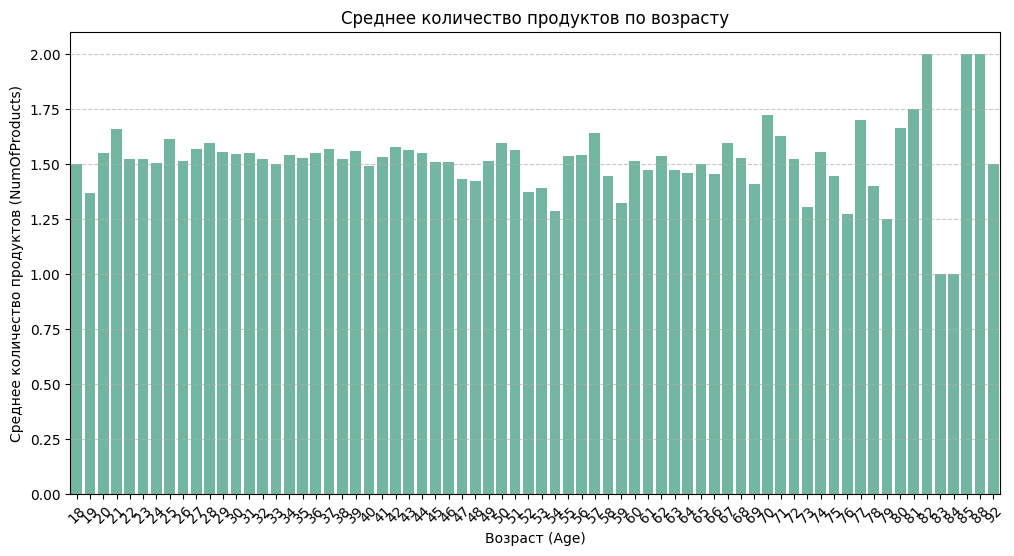

In [17]:
age_product = df.groupby('Age')['NumOfProducts'].mean().reset_index()

plt.figure(figsize=(12, 6))
sns.barplot(x='Age', y='NumOfProducts', data=age_product)
plt.title('Среднее количество продуктов по возрасту')
plt.xlabel('Возраст (Age)')
plt.ylabel('Среднее количество продуктов (NumOfProducts)')
plt.xticks(rotation=45)  
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

### Age и IsActiveMember

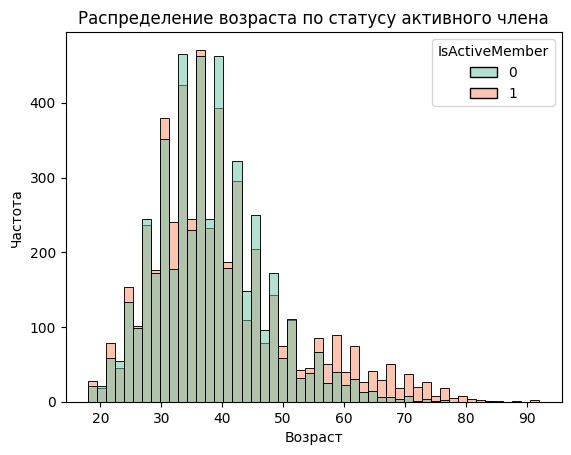

In [30]:
sns.histplot(df, x='Age', bins=50, hue='IsActiveMember')
plt.xlabel('Возраст')
plt.ylabel('Частота')
plt.title('Распределение возраста по статусу активного члена')

plt.show()

### Balance и NumOfProducts

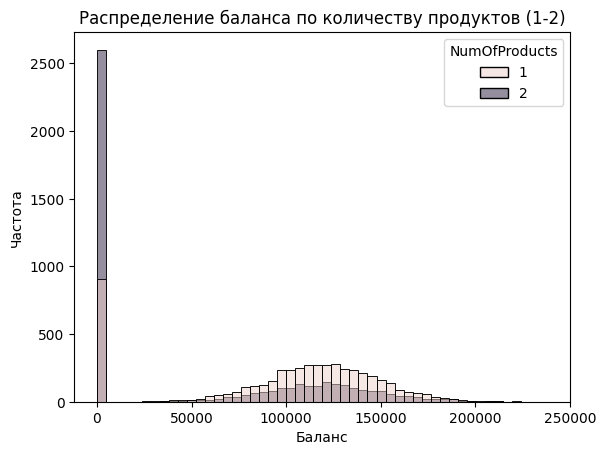

In [31]:
sns.histplot(df.query("NumOfProducts == 1 or NumOfProducts == 2"), x='Balance', bins=50, hue='NumOfProducts')
plt.xlabel('Баланс')
plt.ylabel('Частота')
plt.title('Распределение баланса по количеству продуктов (1-2)')

plt.show()

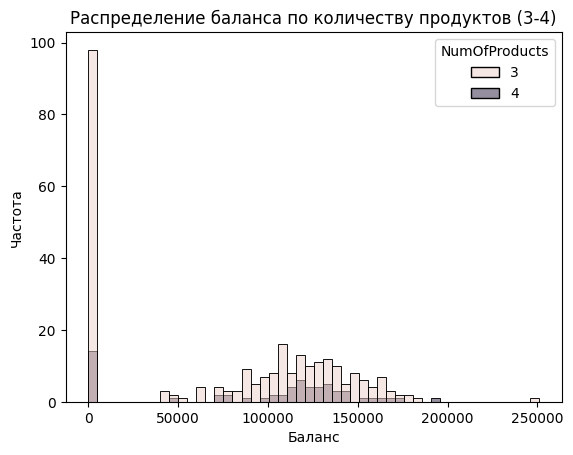

In [32]:
sns.histplot(df.query("NumOfProducts == 3 or NumOfProducts == 4"), x='Balance', bins=50, hue='NumOfProducts')
plt.xlabel('Баланс')
plt.ylabel('Частота')
plt.title('Распределение баланса по количеству продуктов (3-4)')

plt.show()

### Проверка мультиколлинеарности

In [14]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

def calculate_vif(df, features):
    X = df[features].dropna()
    vif = pd.DataFrame()
    vif['Feature'] = features
    vif['VIF'] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
    return vif

vif_df = calculate_vif(df, numerical_cols)
print("\nVIF (Проверка мультиколлинеарности):\n", vif_df)


VIF (Проверка мультиколлинеарности):
             Feature        VIF
0         RowNumber   4.002844
1        CustomerId  83.184609
2       CreditScore  46.347812
3               Age  16.405859
4            Tenure   4.011030
5           Balance   2.793324
6     NumOfProducts   8.742618
7         HasCrCard   3.398460
8    IsActiveMember   2.158265
9   EstimatedSalary   4.034073
10           Exited   1.438506


**Выводы:** `CustomerIdz` - идентификатор, в будущем будет удален. `CreditScore` - высокая мультиколлинеарность, но значимой корреляции с другими признаками нет. Лучше не удалять, т.к. с бизнесовой точки зрения - это важная характеристика клиента. У `Age` уже менее критичная и `NumOfProducts` мультиколлинеарность, корреляция между этими признаками тоже не сильно большая. Примемем решение на этапе создания модели. По остальным признакам неавысокие значения VIF.

# Выводы

1. Датасет не содержит дублей и пропущенных значений. Из потенциальных ошибок - признак `EstimatedSalary` не похож на реальное распределение зарплат (т.к. его распределение равномерно)
2. Для дальнейшего анализа можно смело избавиться от первых трех колонок (`RowNumber`, `CustomerID`, `Surname`), так как они не несут особо смысла.
3. Переменные с дисбалансом в классах / смещенным распределением:
    - `Exited` (целевая): соотношение классов 20 / 80
    - `Geography`: соотношение классов примерно 50 / 25 / 25
    - `Age`: распределение смещено влево, нужно преобразование 
    - `Balance`: около трети клиентов имеют нулевой баланс, распределение клиентов с ненулым балансов близко к нормальному
    - `NumOfProducts`: мало клиентов, имещих 3 или 4 прдукта -> можно их объединить в один класс
    - `HasCrCard`: соотношение классов 30 / 70
4. Целевая переменная `Exited` больше всего зависит от:
    - `NumOfProducts`, `Age` - но есть вероятность, что это из-за смещенных и дисбалансированных распределений
    - `IsActiveMember`
    - `Gender`
    - `Geography`
5. Зависимости между нецелевыми переменными:
    - `Geography` и `Balance` - вызвано тем, что в Германии нет клиентов с нулевым балансом 
    - `Age` и `NumOfProducts` - кажется, что у клиентов старшего возраста больше продуктов, но, возможно, это искажение из-за того, что молодых клиентов больше + классы не сбалансированы. Решение об этих признаках будет принято на этапе создания модели
    - `Age` и `IsActiveMember` - аналогично
    - `Balance` и `NumOfProducts` - в целом форма распределения похожа, но надо быть осторожнее, тк классы `NumOfProducts` не сбаланисрованы

В целом, данные ОК. Я бы выстраивала стратегию по их обработке в зависимости от результатов обучения моделей. Стат. значимость надо проверять осторожнее, т.к. много классов разных размеров